In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/rhuebner/human-resources-data-set')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ayanmamquliyeva
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rhuebner/human-resources-data-set


100%|██████████| 16.6k/16.6k [00:00<00:00, 20.7MB/s]

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df=pd.read_csv('/content/human-resources-data-set/HRDataset_v14.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

#Cleaning

In [5]:
df = df.drop_duplicates()
df

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


In [6]:
def clean_numeric(col):
    return (
        col.astype(str)
        .str.replace("_", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan)
        .astype(float))
df


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


In [7]:
print(f"Missing\n{df.isnull().sum()}")

Missing
Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
Perfor

In [8]:
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')  # səhvli dəyərləri NaN edəcək
df['Salary'] = df['Salary'].astype('Int64')  # int tipinə çevirir, NaN-ları saxlayır

# Nəticəni yoxlamaq
print(df.dtypes)
print(df['Salary'].head())

Employee_Name                  object
EmpID                           int64
MarriedID                       int64
MaritalStatusID                 int64
GenderID                        int64
EmpStatusID                     int64
DeptID                          int64
PerfScoreID                     int64
FromDiversityJobFairID          int64
Salary                          Int64
Termd                           int64
PositionID                      int64
Position                       object
State                          object
Zip                             int64
DOB                            object
Sex                            object
MaritalDesc                    object
CitizenDesc                    object
HispanicLatino                 object
RaceDesc                       object
DateofHire                     object
DateofTermination              object
TermReason                     object
EmploymentStatus               object
Department                     object
ManagerName 

In [9]:
df['ManagerID'] = pd.to_numeric(df['ManagerID'], errors='coerce')  # səhvli dəyərləri NaN edəcək
df['ManagerID'] = df['ManagerID'].astype('Int64')
df.dtypes

,0
Employee_Name,object
EmpID,int64
MarriedID,int64
MaritalStatusID,int64
GenderID,int64
EmpStatusID,int64
DeptID,int64
PerfScoreID,int64
FromDiversityJobFairID,int64
Salary,Int64


In [10]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Salary'] >= Q1 - 1.5*IQR) &
        (df['Salary'] <= Q3 + 1.5*IQR)]
df


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Amy Dunn,11,LinkedIn,Exceeds,5.00,5,0,1/7/2019,0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,"Wolk, Hang T",10174,0,0,0,1,5,3,0,60446,...,David Stanley,14,LinkedIn,Fully Meets,3.40,4,0,2/21/2019,0,14
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12,Google Search,PIP,3.20,2,0,9/2/2015,5,4
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


In [11]:
df['PerformanceScore'].unique()

array(['Exceeds', 'Fully Meets', 'Needs Improvement', 'PIP'], dtype=object)

In [12]:
df['ManagerName'] = df['ManagerName'].str.split().str[0]

/tmp/ipython-input-270988013.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ManagerName'] = df['ManagerName'].str.split().str[0]


In [13]:
df['Salary'].min()

np.int64(45046)

In [14]:
df['Salary'].max()

np.int64(96820)

In [15]:
df['Position'].value_counts()

,count
Position,
Production Technician I,137
Production Technician II,57
Area Sales Manager,27
Production Manager,14
IT Support,8
Data Analyst,7
Software Engineer,5
Network Engineer,5
Sr. Network Engineer,4


In [16]:
df['LastPerformanceReview_Date'] = pd.to_datetime(df['LastPerformanceReview_Date'])
df['LastPerformanceReview_Date'] = df['LastPerformanceReview_Date'].dt.strftime('%d.%m.%y')
df

/tmp/ipython-input-1920975082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LastPerformanceReview_Date'] = pd.to_datetime(df['LastPerformanceReview_Date'])
/tmp/ipython-input-1920975082.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LastPerformanceReview_Date'] = df['LastPerformanceReview_Date'].dt.strftime('%d.%m.%y')


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael,22,LinkedIn,Exceeds,4.60,5,0,17.01.19,0,1
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy,20,LinkedIn,Fully Meets,3.02,3,0,15.05.12,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah,16,Indeed,Fully Meets,4.84,5,0,03.01.19,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster,39,Google Search,Fully Meets,5.00,4,0,01.02.16,0,2
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Amy,11,LinkedIn,Exceeds,5.00,5,0,07.01.19,0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,"Wolk, Hang T",10174,0,0,0,1,5,3,0,60446,...,David,14,LinkedIn,Fully Meets,3.40,4,0,21.02.19,0,14
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy,20,LinkedIn,Fully Meets,4.07,4,0,28.02.19,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon,12,Google Search,PIP,3.20,2,0,02.09.15,5,4
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon,4,Employee Referral,Fully Meets,5.00,3,5,01.02.19,0,11


In [17]:
df[['Employee_Firstname','Employee_Surname']] = df['Employee_Name'].str.split(',', expand=True)
df['Employee_Firstname'] = df['Employee_Firstname'].str.strip()
df['Employee_Surname'] = df['Employee_Surname'].str.strip()
df

/tmp/ipython-input-4122462966.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Employee_Firstname','Employee_Surname']] = df['Employee_Name'].str.split(',', expand=True)
/tmp/ipython-input-4122462966.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Employee_Firstname','Employee_Surname']] = df['Employee_Name'].str.split(',', expand=True)
/tmp/ipython-input-4122462966.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,Employee_Firstname,Employee_Surname
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,LinkedIn,Exceeds,4.60,5,0,17.01.19,0,1,Adinolfi,Wilson K
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,LinkedIn,Fully Meets,3.02,3,0,15.05.12,0,3,Akinkuolie,Sarah
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Indeed,Fully Meets,4.84,5,0,03.01.19,0,15,Alagbe,Trina
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Google Search,Fully Meets,5.00,4,0,01.02.16,0,2,Anderson,Carol
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,LinkedIn,Exceeds,5.00,5,0,07.01.19,0,15,Anderson,Linda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,"Wolk, Hang T",10174,0,0,0,1,5,3,0,60446,...,LinkedIn,Fully Meets,3.40,4,0,21.02.19,0,14,Wolk,Hang T
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,LinkedIn,Fully Meets,4.07,4,0,28.02.19,0,13,Woodson,Jason
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Google Search,PIP,3.20,2,0,02.09.15,5,4,Ybarra,Catherine
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Employee Referral,Fully Meets,5.00,3,5,01.02.19,0,11,Zhou,Julia


In [18]:
df['DateofTermination'].isna().sum()

np.int64(188)

In [19]:
df['DOB'].unique()

array(['07/10/83', '09/19/88', '09/27/88', '09/08/89', '05/22/77',
       '05/24/79', '02/18/83', '02/11/70', '01/07/88', '01/12/74',
       '02/21/74', '07/04/88', '07/20/83', '07/15/77', '10/18/81',
       '04/17/66', '10/27/70', '04/06/79', '12/22/70', '12/27/58',
       '09/01/89', '09/21/90', '01/16/67', '03/10/70', '08/24/90',
       '11/24/87', '07/28/83', '10/30/69', '06/01/64', '03/02/80',
       '08/19/77', '11/22/66', '08/09/83', '04/05/87', '02/02/83',
       '05/15/63', '01/02/51', '02/12/79', '08/24/83', '06/11/70',
       '08/27/83', '05/31/88', '09/05/85', '08/31/81', '11/25/78',
       '08/26/80', '09/08/77', '08/12/79', '12/17/75', '03/31/77',
       '08/26/86', '04/10/87', '09/09/65', '04/19/90', '01/18/52',
       '11/05/78', '09/14/79', '04/15/88', '10/31/77', '11/02/75',
       '02/25/51', '04/19/67', '09/04/83', '11/15/82', '05/14/87',
       '12/02/78', '10/07/86', '07/18/88', '11/08/88', '11/28/73',
       '09/23/73', '09/05/91', '05/31/74', '08/25/78', '08/25/

In [20]:
df['DOB'] = pd.to_datetime(df['DOB'])
df['DOB'] = df['DOB'].dt.strftime('%d.%m.%y')
df

/tmp/ipython-input-3316019431.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DOB'] = pd.to_datetime(df['DOB'])
/tmp/ipython-input-3316019431.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DOB'] = pd.to_datetime(df['DOB'])
/tmp/ipython-input-3316019431.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DOB'] = df['DOB'].dt.strftime('%d.%m.%y')


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,Employee_Firstname,Employee_Surname
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,LinkedIn,Exceeds,4.60,5,0,17.01.19,0,1,Adinolfi,Wilson K
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,LinkedIn,Fully Meets,3.02,3,0,15.05.12,0,3,Akinkuolie,Sarah
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Indeed,Fully Meets,4.84,5,0,03.01.19,0,15,Alagbe,Trina
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Google Search,Fully Meets,5.00,4,0,01.02.16,0,2,Anderson,Carol
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,LinkedIn,Exceeds,5.00,5,0,07.01.19,0,15,Anderson,Linda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,"Wolk, Hang T",10174,0,0,0,1,5,3,0,60446,...,LinkedIn,Fully Meets,3.40,4,0,21.02.19,0,14,Wolk,Hang T
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,LinkedIn,Fully Meets,4.07,4,0,28.02.19,0,13,Woodson,Jason
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Google Search,PIP,3.20,2,0,02.09.15,5,4,Ybarra,Catherine
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Employee Referral,Fully Meets,5.00,3,5,01.02.19,0,11,Zhou,Julia


In [21]:
df['DOB'].unique()

array(['10.07.83', '19.09.88', '27.09.88', '08.09.89', '22.05.77',
       '24.05.79', '18.02.83', '11.02.70', '07.01.88', '12.01.74',
       '21.02.74', '04.07.88', '20.07.83', '15.07.77', '18.10.81',
       '17.04.66', '27.10.70', '06.04.79', '22.12.70', '27.12.58',
       '01.09.89', '21.09.90', '16.01.67', '10.03.70', '24.08.90',
       '24.11.87', '28.07.83', '30.10.69', '01.06.64', '02.03.80',
       '19.08.77', '22.11.66', '09.08.83', '05.04.87', '02.02.83',
       '15.05.63', '02.01.51', '12.02.79', '24.08.83', '11.06.70',
       '27.08.83', '31.05.88', '05.09.85', '31.08.81', '25.11.78',
       '26.08.80', '08.09.77', '12.08.79', '17.12.75', '31.03.77',
       '26.08.86', '10.04.87', '09.09.65', '19.04.90', '18.01.52',
       '05.11.78', '14.09.79', '15.04.88', '31.10.77', '02.11.75',
       '25.02.51', '19.04.67', '04.09.83', '15.11.82', '14.05.87',
       '02.12.78', '07.10.86', '18.07.88', '08.11.88', '28.11.73',
       '23.09.73', '05.09.91', '31.05.74', '25.08.78', '25.08.

In [22]:
df['DOB'] = pd.to_datetime(df['DOB'])
today = pd.Timestamp.today()
df['Age'] = (today - df['DOB']).dt.days // 365
df

/tmp/ipython-input-1371494002.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DOB'] = pd.to_datetime(df['DOB'])
/tmp/ipython-input-1371494002.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DOB'] = pd.to_datetime(df['DOB'])
/tmp/ipython-input-1371494002.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = (today - df['DOB']).dt.days // 365


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,Employee_Firstname,Employee_Surname,Age
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Exceeds,4.60,5,0,17.01.19,0,1,Adinolfi,Wilson K,42
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Fully Meets,3.02,3,0,15.05.12,0,3,Akinkuolie,Sarah,37
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Fully Meets,4.84,5,0,03.01.19,0,15,Alagbe,Trina,37
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Fully Meets,5.00,4,0,01.02.16,0,2,Anderson,Carol,36
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Exceeds,5.00,5,0,07.01.19,0,15,Anderson,Linda,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,"Wolk, Hang T",10174,0,0,0,1,5,3,0,60446,...,Fully Meets,3.40,4,0,21.02.19,0,14,Wolk,Hang T,40
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Fully Meets,4.07,4,0,28.02.19,0,13,Woodson,Jason,40
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,PIP,3.20,2,0,02.09.15,5,4,Ybarra,Catherine,43
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Fully Meets,5.00,3,5,01.02.19,0,11,Zhou,Julia,47


#Visualization

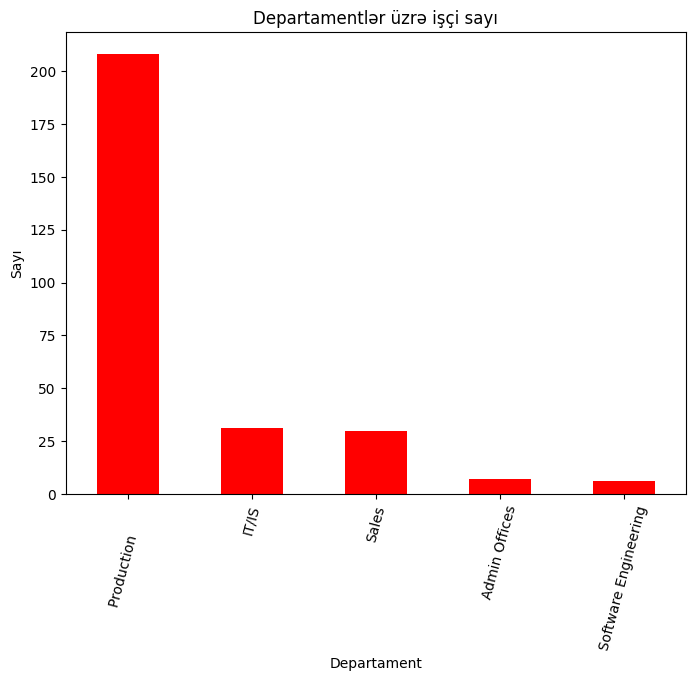

In [23]:
plt.figure(figsize=(8, 6))
df['Department'].value_counts().plot(kind='bar',color="red")
plt.title("Departamentlər üzrə işçi sayı")
plt.xlabel("Departament")
plt.ylabel("Sayı")
plt.xticks(rotation=75)
plt.show()


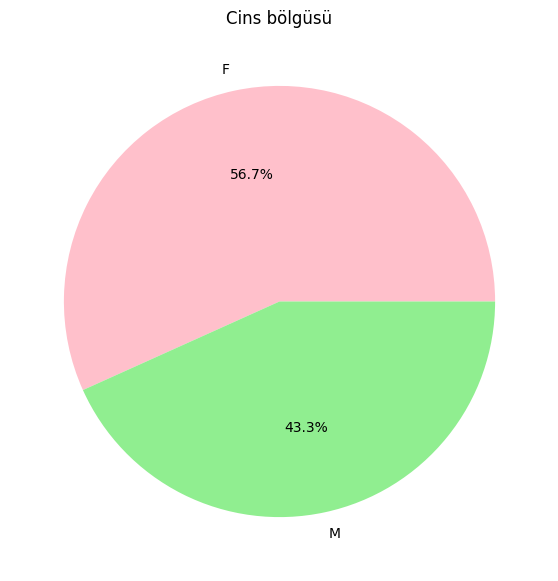

In [24]:
plt.figure(figsize=(7, 7))
colors = ['pink', 'lightgreen']
df['Sex'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors)
plt.title("Cins bölgüsü")
plt.ylabel("")
plt.show()


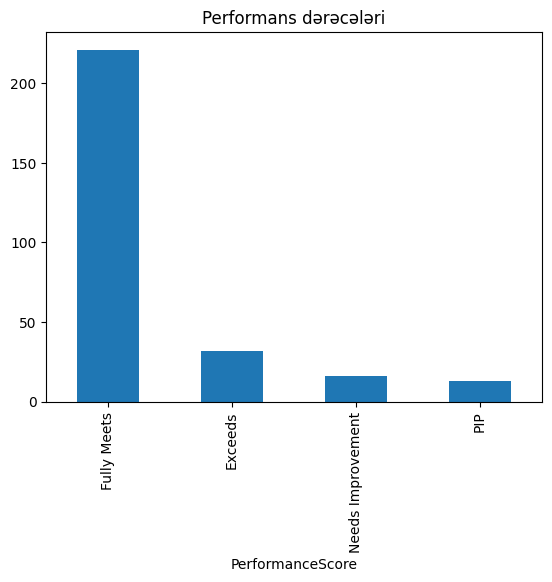

In [25]:
plt.figure()
df['PerformanceScore'].value_counts().plot(kind='bar')
plt.title("Performans dərəcələri")
plt.show()


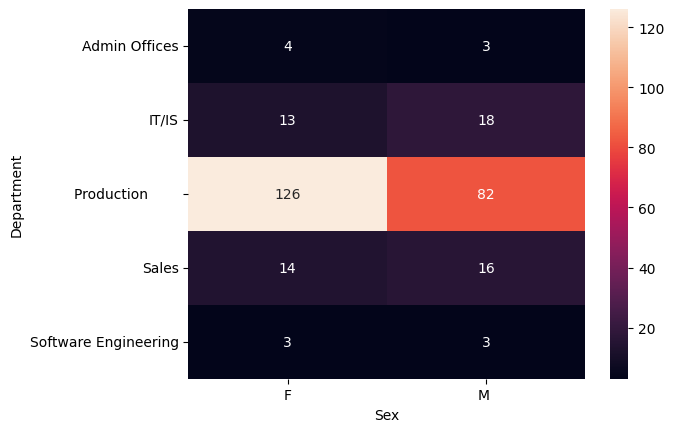

In [26]:
table = pd.crosstab(df['Department'], df['Sex'])
sns.heatmap(table, annot=True, fmt='d')
plt.show()


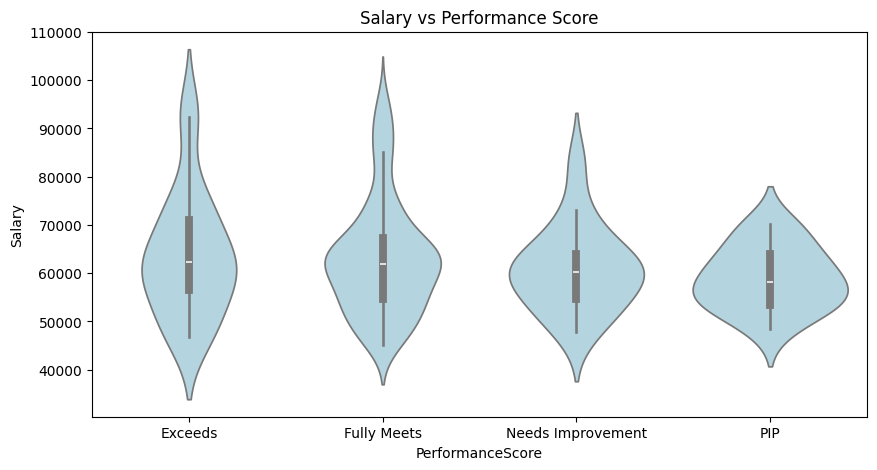

In [27]:
plt.figure(figsize=(10,5))
sns.violinplot(x="PerformanceScore", y="Salary", data=df,color='lightblue')
plt.title("Salary vs Performance Score")
plt.xticks(rotation=0)
plt.show()

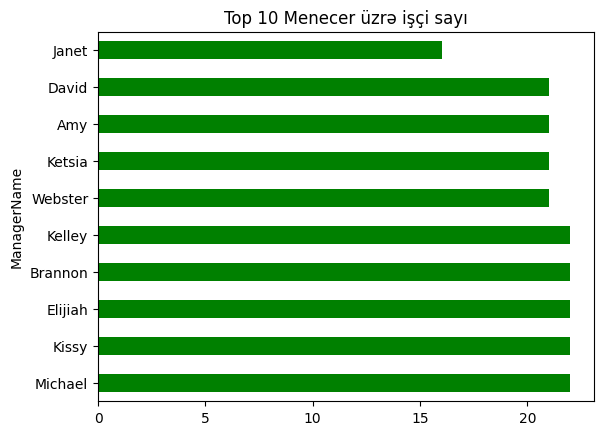

In [28]:
df['ManagerName'].value_counts().head(10).plot(kind='barh',color='g')
plt.title("Top 10 Menecer üzrə işçi sayı")
plt.show()


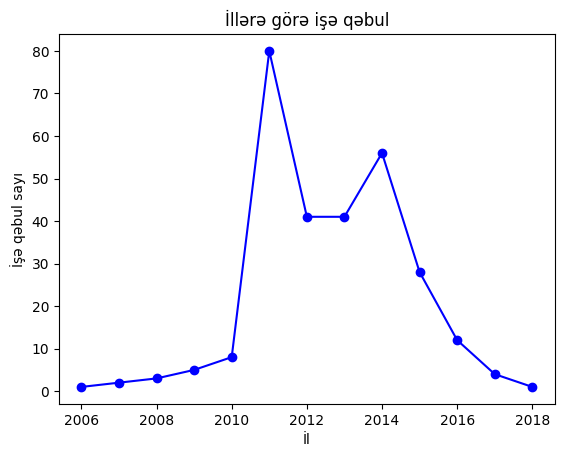

In [29]:
hire_year = pd.to_datetime(df['DateofHire']).dt.year.value_counts().sort_index()

plt.plot(hire_year.index, hire_year.values, marker='o',color='blue')
plt.xlabel("İl")
plt.ylabel("İşə qəbul sayı")
plt.title("İllərə görə işə qəbul")
plt.show()


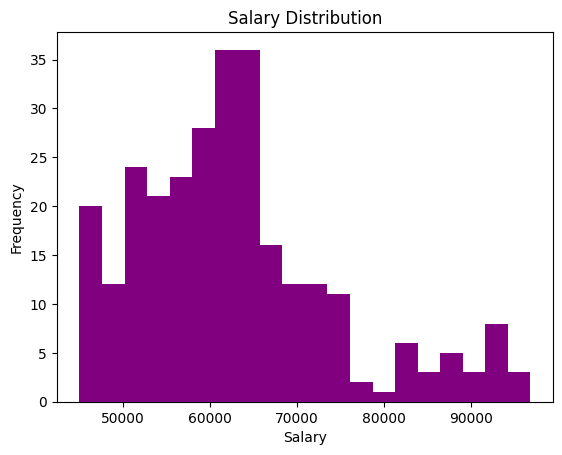

In [30]:
plt.hist(df["Salary"], bins=20,color='purple')
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

/tmp/ipython-input-3195452694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Department', y='Salary', data=df, palette='Set2')


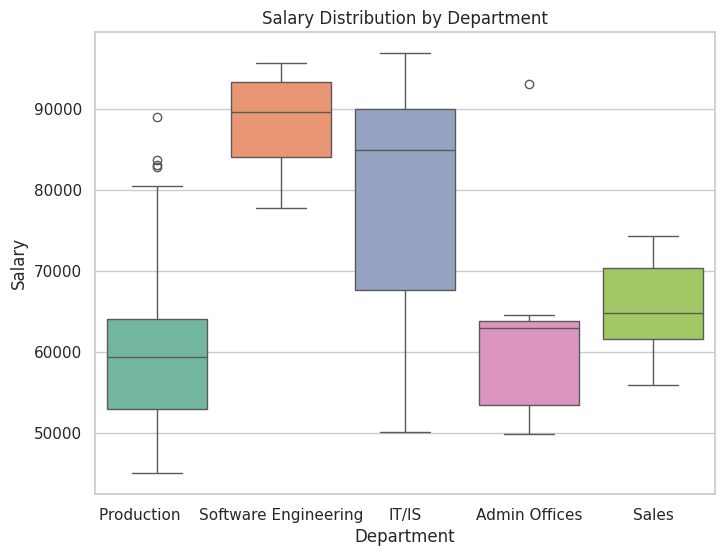

In [31]:
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
sns.boxplot(x='Department', y='Salary', data=df, palette='Set2')
plt.title('Salary Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.show()

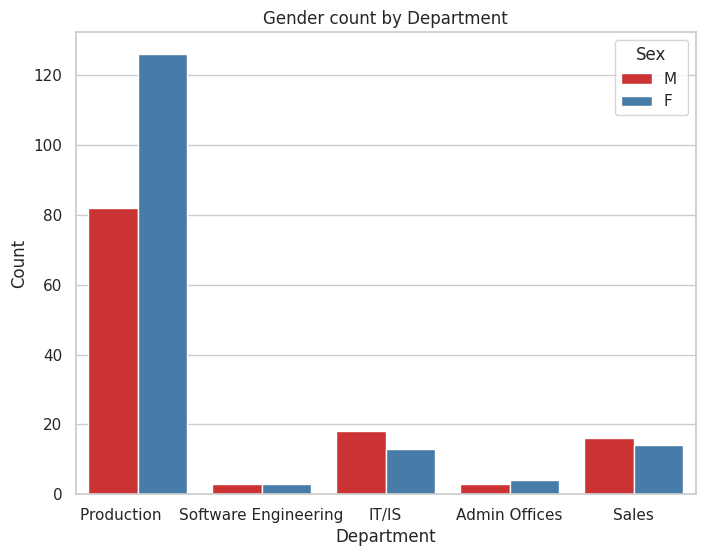

In [32]:
plt.figure(figsize=(8,6))
sns.countplot(x='Department', hue='Sex', data=df, palette='Set1')

plt.title('Gender count by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show()


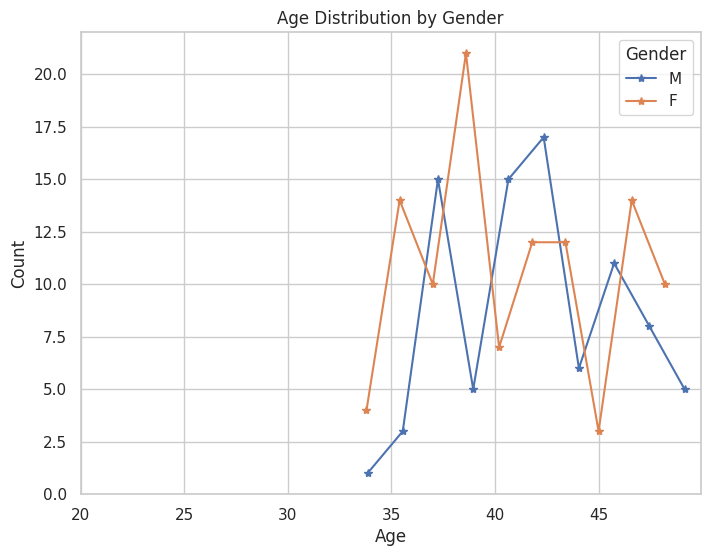

In [33]:
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))

genders = df['Sex'].unique()
for gender in genders:
    ages = df[df['Sex'] == gender]['Age']
    # age-ləri 0-dan yuxarı ilə məhdudlaşdırırıq
    ages = ages[ages >= 0]
    counts, bins = np.histogram(ages, bins=10)
    bins_center = 0.5 * (bins[1:] + bins[:-1])
    plt.plot(bins_center, counts, marker='*', label=gender)

plt.title('Age Distribution by Gender')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xlim(20, None)  # x-oxunu 0-dan başlat
plt.legend(title='Gender')
plt.show()

In [34]:
# df.to_csv('HRData_Set.csv', index=False)

In [35]:
# from google.colab import files
# files.download('HRData_Sett.csv')